In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow as pa
import pyarrow.parquet as pq

In [2]:
df = pd.read_parquet("data/drone.parquet", engine="pyarrow")
df

,flight,time,wind_speed,wind_angle,battery_voltage,battery_current,position_x,position_y,position_z,orientation_x,...,angular_z,linear_acceleration_x,linear_acceleration_y,linear_acceleration_z,speed,payload,altitude,date,time_day,route
0,1,0.00,0.1,12.0,24.222174,0.087470,-79.782396,40.458047,269.332402,0.001772,...,0.006815,0.004258,-0.120405,-9.811137,4.0,0.0,25,2019-04-07,10:13,R5
1,1,0.20,0.1,3.0,24.227180,0.095421,-79.782396,40.458047,269.332056,0.001768,...,0.002034,0.006175,-0.116397,-9.810392,4.0,0.0,25,2019-04-07,10:13,R5
2,1,0.30,0.1,352.0,24.225929,0.095421,-79.782396,40.458047,269.333081,0.001768,...,-0.000874,0.002696,-0.128592,-9.809440,4.0,0.0,25,2019-04-07,10:13,R5
3,1,0.50,0.1,354.0,24.224678,0.095421,-79.782396,40.458047,269.334648,0.001775,...,0.002443,0.002024,-0.128271,-9.810159,4.0,0.0,25,2019-04-07,10:13,R5
4,1,0.60,0.1,359.0,24.210905,0.079518,-79.782396,40.458047,269.336178,0.001775,...,-0.006425,0.008271,-0.119890,-9.812125,4.0,0.0,25,2019-04-07,10:13,R5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
257891,279,152.10,1.1,198.0,22.857437,0.095421,-79.782802,40.459018,271.560190,0.021382,...,0.009449,0.444553,-0.274965,-9.796700,10.0,0.0,25-50-100-25,2019-10-24,10:10,R7
257892,279,152.20,1.1,196.0,22.847422,0.095421,-79.782802,40.459018,271.571983,0.021383,...,-0.001755,0.451230,-0.240619,-9.793810,10.0,0.0,25-50-100-25,2019-10-24,10:10,R7
257893,279,152.41,1.2,189.0,22.856186,0.111325,-79.782802,40.459018,271.584533,0.021385,...,0.008545,0.443839,-0.274903,-9.796004,10.0,0.0,25-50-100-25,2019-10-24,10:10,R7
257894,279,152.60,1.1,187.0,22.854933,0.127228,-79.782802,40.459018,271.588050,0.021393,...,-0.001379,0.443880,-0.248434,-9.794703,10.0,0.0,25-50-100-25,2019-10-24,10:10,R7


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 257896 entries, 0 to 257895
Data columns (total 28 columns):
 #   Column                 Non-Null Count   Dtype   
---  ------                 --------------   -----   
 0   flight                 257896 non-null  int64   
 1   time                   257896 non-null  float64 
 2   wind_speed             257896 non-null  float64 
 3   wind_angle             257896 non-null  float64 
 4   battery_voltage        257896 non-null  float64 
 5   battery_current        257896 non-null  float64 
 6   position_x             257896 non-null  float64 
 7   position_y             257896 non-null  float64 
 8   position_z             257896 non-null  float64 
 9   orientation_x          257896 non-null  float64 
 10  orientation_y          257896 non-null  float64 
 11  orientation_z          257896 non-null  float64 
 12  orientation_w          257896 non-null  float64 
 13  velocity_x             257896 non-null  float64 
 14  velocity_y             257896 n

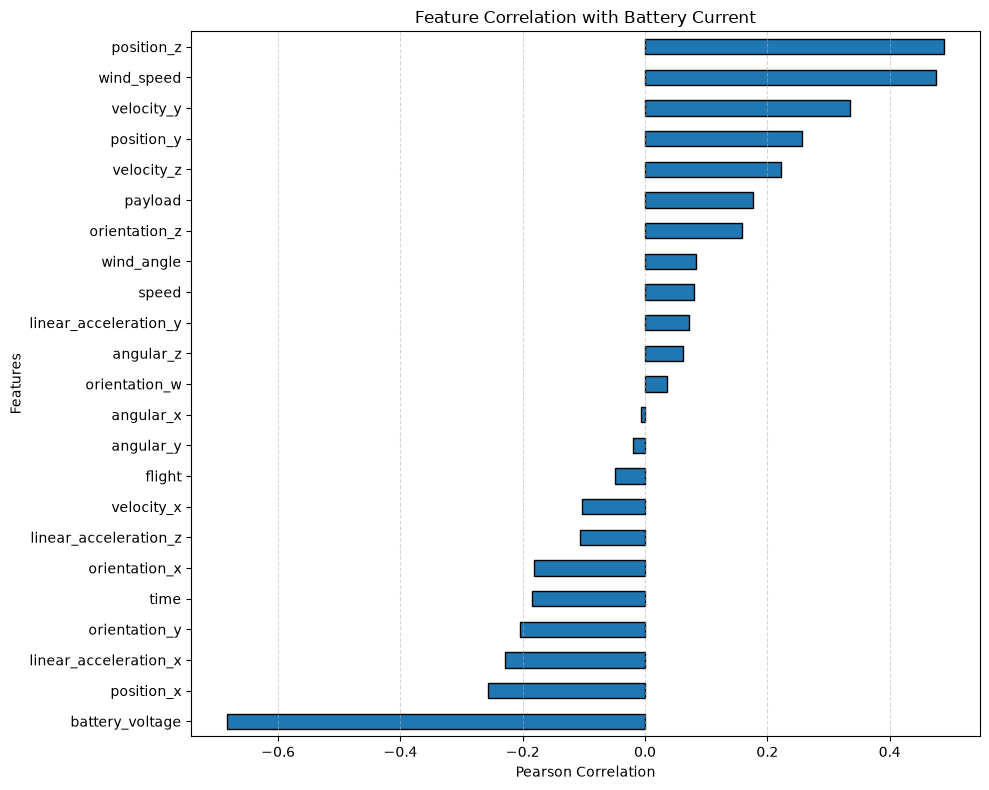

In [8]:
# Compute correlation matrix
corr = df.corr(numeric_only=True)

# Correlation with target
target_corr = (
    corr["battery_current"]
    .drop("battery_current")      # Remove self-correlation
    .sort_values()
)

plt.figure(figsize=(10, 8))

target_corr.plot(
    kind="barh",                  # Horizontal bar chart
    edgecolor="black"
)

plt.title("Feature Correlation with Battery Current")
plt.xlabel("Pearson Correlation")
plt.ylabel("Features")

plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()